In [1]:
import os
import random
import tempfile
import numpy as np
import pandas as pd
from pathlib import Path
from IPython.display import Image, display

# Visualization libraries
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import colors as cls
from matplotlib.ticker import FormatStrFormatter
import plotly.express as px

# Data preprocessing and machine learning libraries
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
import keras
from keras.models import Sequential
from keras.layers import Input, Dense, Dropout
from keras.optimizers import Adam

# Physics related libraries
from ase import Atoms
try:
    from ovito.io import import_file
except ImportError:
    print('Please install OVITO visualization tool. It is required for visulizing particles in this notebook.')
from ovito.vis import Viewport, TachyonRenderer

# Helper functions
from utils.helpers import merge_clusters, _compute_ICL_ent
from utils.process import process_systems, get_system_qvals, add_distances

In [2]:
# Seed initializations, package configurations, and setting constant values

np.random.seed(142)
tf.random.set_seed(142)
random.seed(142)
keras.utils.set_random_seed(142)

colors = ['magenta', 'turquoise', 'royalblue',  'orange', 'darkgreen']


data_path = Path('result_dump_files')
bops = [2, 3, 4, 5, 6, 7, 8, 9]
averaged = False
method = 'cutoff'
fixed_cutoff = 1.055

# The gap is the distance between the systems in the combined system
gaps = 34.
data_files = ['mu4_eps0.xyz', 'mu4_eps1.xyz', 'mu4_eps3.25.xyz',
            'mu2_eps0.xyz', 'mu2_eps1.xyz', 'mu2_eps3.25.xyz',
            'mu0_eps0.xyz', 'mu0_eps1.xyz', 'mu0_eps3.25.xyz']
matplotlib.rc('axes', labelsize=20)
matplotlib.rc('xtick', labelsize=18)
matplotlib.rc('ytick', labelsize=18)

### Calculating qs for input file from LAMMPS for Ply-Crystaline HCP FCC Crystal

In [3]:
print(f"Processing file 1 ({data_files[0]}) of {len(data_files)} files")
first_file_path = str(data_path.joinpath(data_files[0]).resolve())


atoms, middles = process_systems(first_file_path, method=method, cutoff=fixed_cutoff)
box_dims = atoms.cell.lengths()
combined_box_dimensions = [[3*box_dims[0]+gaps, 0, 0], [0, 3*box_dims[1]+gaps, 0], [0, 0, 3*box_dims[2]+gaps]]

for i, file_name in enumerate(data_files):
    print(f"Processing file {i+2} ({file_name}) of {len(data_files)} files")
    
    file_path = str(data_path.joinpath(file_name).resolve())
    atoms, _ = process_systems(file_path, method=method, cutoff=fixed_cutoff)
    qvals = get_system_qvals(atoms, bops, averaged=averaged)
    if i == 0:
        combined_order_parameters = np.copy(qvals)
    else:
        combined_order_parameters = np.vstack((combined_order_parameters, np.copy(qvals)))

    match i:
        case 1:
            add_distances(atoms, axis=0, coeff=1, gap=gaps/2)
        case 2:	
            add_distances(atoms, axis=0, coeff=2, gap=gaps/2)
        case 3:
            add_distances(atoms, axis=1, coeff=1, gap=gaps/2)
        case 4:
            add_distances(atoms, axis=1, coeff=1, gap=gaps/2)
            add_distances(atoms, axis=0, coeff=1, gap=gaps/2)
        case 5:
            add_distances(atoms, axis=1, coeff=1, gap=gaps/2)
            add_distances(atoms, axis=0, coeff=2, gap=gaps/2)
        case 6:
            add_distances(atoms, axis=1, coeff=2, gap=gaps/2)
        case 7:
            add_distances(atoms, axis=1, coeff=2, gap=gaps/2)
            add_distances(atoms, axis=0, coeff=1, gap=gaps/2)
        case 8:
            add_distances(atoms, axis=1, coeff=2, gap=gaps/2)
            add_distances(atoms, axis=0, coeff=2, gap=gaps/2)
    
    if i == 0:
        positions = np.copy(atoms.get_positions())
    else:
        positions = np.vstack((positions, np.copy(atoms.get_positions())))
combined_atoms = Atoms(positions=positions, cell=combined_box_dimensions, pbc=[1, 1, 1])


Processing file 1 (mu4_eps0.xyz) of 9 files
Processing file 2 (mu4_eps0.xyz) of 9 files
Processing file 3 (mu4_eps1.xyz) of 9 files
Processing file 4 (mu4_eps3.25.xyz) of 9 files
Processing file 5 (mu2_eps0.xyz) of 9 files
Processing file 6 (mu2_eps1.xyz) of 9 files
Processing file 7 (mu2_eps3.25.xyz) of 9 files
Processing file 8 (mu0_eps0.xyz) of 9 files
Processing file 9 (mu0_eps1.xyz) of 9 files
Processing file 10 (mu0_eps3.25.xyz) of 9 files


In [4]:
number_of_nans = np.isnan(combined_order_parameters[:,6]).sum()
print(f"Number of undefined values in each order parameter: {number_of_nans}")
train_test_dataset = np.copy(combined_order_parameters[~np.isnan(combined_order_parameters[:,6])])
df = pd.DataFrame(train_test_dataset, columns=[f"q{bop}" for bop in bops])
display(df.describe())

Number of undefined values in each order parameter: 10921


,q2,q3,q4,q5,q6,q7,q8,q9
count,61079.000000,61079.000000,61079.000000,61079.000000,61079.000000,61079.000000,61079.000000,61079.000000
mean,0.533755,0.481066,0.562743,0.545890,0.709299,0.551489,0.586183,0.523656
std,0.283855,0.294535,0.254858,0.266462,0.164704,0.261538,0.228943,0.269613
min,0.010927,0.002503,0.038801,0.003957,0.261714,0.005407,0.055110,0.006854
25%,0.311855,0.258450,0.359763,0.340989,0.593956,0.351821,0.415054,0.319451
50%,0.470501,0.367130,0.471372,0.475062,0.656211,0.487808,0.504976,0.426244
75%,0.697305,0.664589,0.714637,0.737876,0.809877,0.729066,0.694078,0.686942
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [5]:
input_dim = len(bops)
learning_rate = 4e-5
n_epochs = 180
latent_dim = 3
batch_size = 512
percent_training = 0.75
n_train = int(train_test_dataset.shape[0] * percent_training)
print(f"Total number of samples: {train_test_dataset.shape[0]}")
print(f"Number of training samples: {n_train}")
print(f"Number of test samples: {train_test_dataset.shape[0] - n_train}")

Total number of samples: 61079
Number of training samples: 45809
Number of test samples: 15270


In [6]:
stacked_encoder = Sequential([
    Input(shape=[input_dim], name='encoder_input'),
    Dense(20, activation="relu", name='encoder_l1', kernel_initializer="glorot_normal"),
    Dropout(0.05),
    Dense(70, activation="relu", name='encoder_l2', kernel_initializer="glorot_normal"),
    Dropout(0.15),
	Dense(latent_dim, activation='relu', name='encoder_l3', kernel_initializer="glorot_normal"),
])
stacked_decoder = Sequential([
    Input(shape=[latent_dim], name='decoder_input'),
    Dense(20, activation="relu", name='decoder_l1', kernel_initializer="glorot_normal"),
    Dropout(0.05),
    Dense(70, activation="relu", name='decoder_l2', kernel_initializer="glorot_normal"),
    Dropout(0.15),
	Dense(input_dim, activation='linear', name='decoder_l3'),
])
stacked_ae = Sequential([stacked_encoder, stacked_decoder])

In [7]:
np.random.shuffle(train_test_dataset)
qs_train, qs_test = train_test_dataset[:n_train, :], train_test_dataset[n_train:, :]
scaler = StandardScaler()
qs_train = scaler.fit_transform(qs_train).astype(dtype=np.float64)
qs_test = scaler.fit_transform(qs_test).astype(dtype=np.float64)

stacked_ae.compile(
    loss='mean_squared_error', 
    optimizer = Adam(learning_rate=learning_rate, weight_decay=0.01),
metrics=['mean_squared_error', "mean_squared_logarithmic_error"])

history = stacked_ae.fit(qs_train, qs_train, epochs=n_epochs, batch_size=batch_size, validation_data=(qs_test, qs_test))
score = stacked_ae.evaluate(qs_test, qs_test)
print('Test loss:', score[0])
print('Test mean_squared_error:', score[1])

Epoch 1/180
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.9369 - mean_squared_error: 0.9369 - mean_squared_logarithmic_error: 0.1733 - val_loss: 0.9025 - val_mean_squared_error: 0.9025 - val_mean_squared_logarithmic_error: 0.1654
Epoch 2/180
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 939us/step - loss: 0.8747 - mean_squared_error: 0.8747 - mean_squared_logarithmic_error: 0.1533 - val_loss: 0.8242 - val_mean_squared_error: 0.8242 - val_mean_squared_logarithmic_error: 0.1421
Epoch 3/180
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 984us/step - loss: 0.7926 - mean_squared_error: 0.7926 - mean_squared_logarithmic_error: 0.1282 - val_loss: 0.7297 - val_mean_squared_error: 0.7297 - val_mean_squared_logarithmic_error: 0.1107
Epoch 4/180
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 905us/step - loss: 0.6992 - mean_squared_error: 0.6992 - mean_squared_logarithmic_error: 0.1002 - val_loss: 0.6253 - val_mean_squared_error: 0.6253 - val_mean_squared_logarithmic_error: 0.0779
Epoch 5/180
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 940us/step - loss: 0

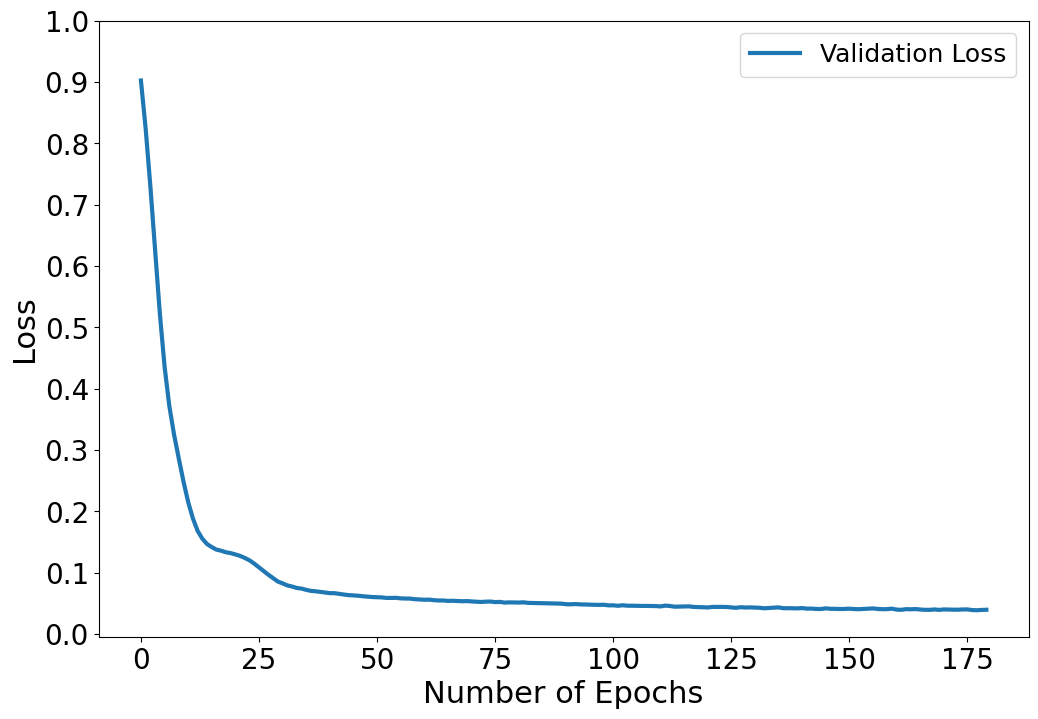

In [8]:
fmt = FormatStrFormatter('%.1f')
plt.figure(figsize=(12,8))

plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=3)
plt.gca().yaxis.set_major_formatter(fmt)
plt.yticks(np.arange(0,1.1,0.1), fontsize=20)
plt.xticks(np.arange(0, n_epochs+10, 25), fontsize=20)

plt.xlabel('Number of Epochs', fontsize=22)
plt.ylabel('Loss', fontsize=22)
plt.legend(fontsize=18)
plt.show()

Model final mean squared error: 0.0259


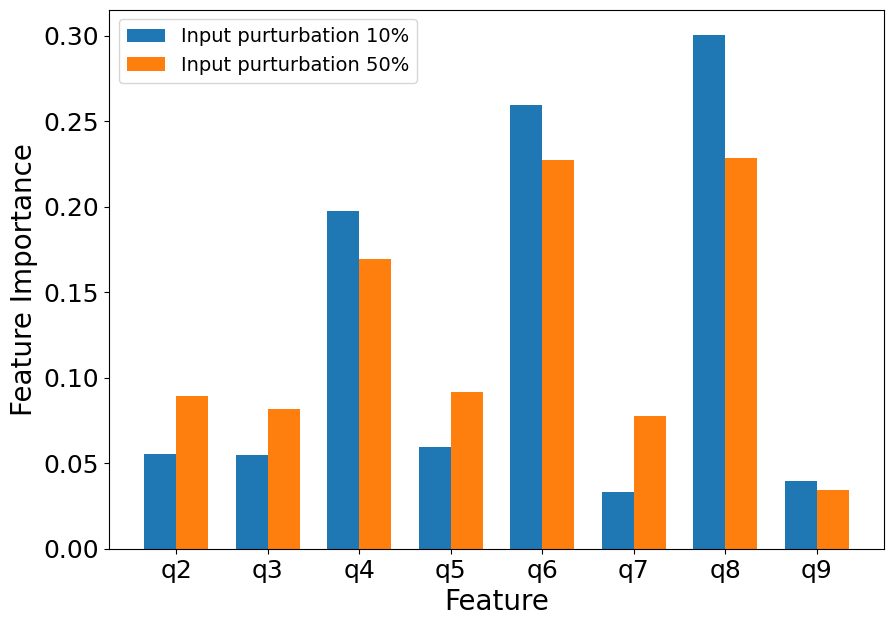

In [9]:
params = [0.1, 0.5]
width= 0.35

fig, ax = plt.subplots(figsize=(10,7))

origin_mse = np.mean((tf.reduce_mean(tf.square(train_test_dataset - stacked_ae(train_test_dataset)), axis=1)).numpy())
print(f"Model final mean squared error: {round(origin_mse, 4):.4f}")
for j ,param in enumerate(params):
    importances = []
    for i in range(train_test_dataset.shape[1]):
        my_rand = np.random.uniform(low=0, high=param, size=(train_test_dataset.shape[0], 1))
        new_col = np.multiply(my_rand, train_test_dataset[:, i].reshape(-1,1))
        purt_train_test_dataset = train_test_dataset.copy()
        purt_train_test_dataset[:, i] = purt_train_test_dataset[:,i] + new_col.flatten()
        mse = tf.reduce_mean(tf.square(purt_train_test_dataset - stacked_ae(train_test_dataset)), axis=1)
        importances.append(abs(np.mean(mse.numpy() - origin_mse)))
    RI = importances/np.sum(importances)
    plt.bar([j*width+x for x in range(2, len(RI)+2)], RI, width=width, label=f'Input purturbation {str(int(param*100))}%')

ax.set_xticks([x+width/2 for x in range(2,len(importances)+2)])
ax.set_xticklabels(['q2', 'q3', 'q4', 'q5', 'q6', 'q7', 'q8', 'q9'],)

ax.tick_params(axis='both', which='major')
ax.set_xlabel("Feature")
ax.set_ylabel("Feature Importance")
ax.legend(fontsize=14)
plt.show()


### Use Gausian Mixture Models on the results of autoencoder

In [10]:
qs_encoded = stacked_encoder(combined_order_parameters).numpy().astype(np.float64)
qs_encoded = np.nan_to_num(qs_encoded, nan=0.001)

### Analyze the GMM results

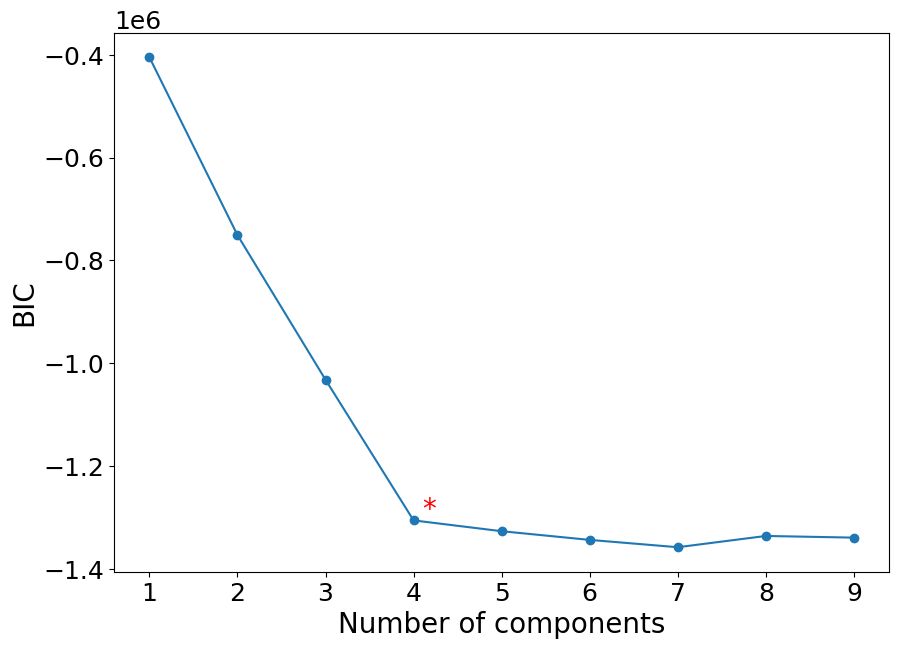

In [11]:
plt.figure(figsize=(10,7))

bic = []
n_components_range = range(1, 10)
for n_components in n_components_range:
    gmm = GaussianMixture(
        n_components=n_components, covariance_type='full', random_state=142)
    gmm.fit(qs_encoded)
    bic.append(gmm.bic(qs_encoded))

bic = np.array(bic)

plt.text(4.1, -1.3e6, "*", fontsize=20, color='red')
plt.xticks(n_components_range)
plt.xlabel("Number of components")
plt.ylabel("BIC")
plt.scatter(n_components_range, bic)
plt.plot(n_components_range, bic)
plt.show()

In [12]:
n_clusters = 4
gmm = GaussianMixture(n_components=n_clusters, 
                    covariance_type="full", random_state=142)
gmm.fit(qs_encoded)
labels = gmm.predict(qs_encoded)
data_with_labels = np.concatenate([qs_encoded, labels.reshape(-1, 1)], axis=1)
df = pd.DataFrame(data_with_labels, columns=['x', 'y', 'z','cluster'])

fig = px.scatter_3d(df, x='x', y='y', z='z',
					color='cluster')
fig.show()


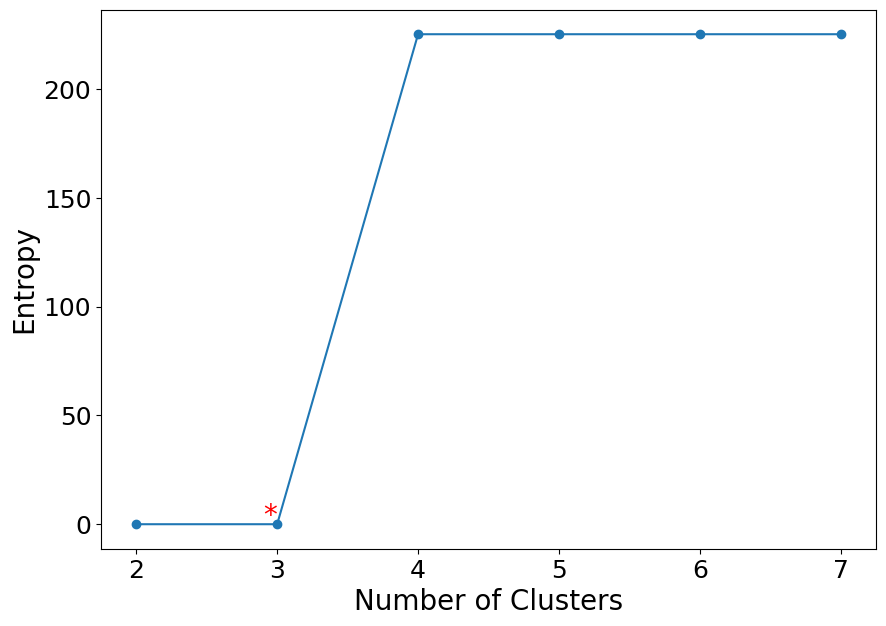

In [13]:
max_clusters = 7
plt.figure(figsize=(10, 7))

# Use weights from GMM to merge the clusters into `n_cluster_min`
# this returns new weights and new labels
weights = gmm.predict_proba(qs_encoded)
weights[np.where(weights < 1e-13)] = 1e-10
s_ls = []
n_range = range(max_clusters, 1, -1)
for i in n_range:
    new_weights, new_labels = merge_clusters(weights, n_clusters_min=i)
    ent = _compute_ICL_ent(new_weights, 1e-15)
    s_ls.append(ent)

s_ls = np.array(s_ls)
plt.scatter(n_range, s_ls)
plt.plot(n_range, s_ls)
plt.text(2.9, s_ls[-1], "*", fontsize=20, color='red')

plt.xlabel("Number of Clusters")
plt.ylabel("Entropy")
plt.show()

In [14]:
n_elbow = 3

In [15]:
gmm = GaussianMixture(n_components=n_elbow, 
                    covariance_type="full", random_state=142)
gmm.fit(qs_encoded)
labels = gmm.predict(qs_encoded)
weights = gmm.predict_proba(qs_encoded)

data_with_labels = np.concatenate([qs_encoded, labels.reshape(-1, 1)], axis=1)
df = pd.DataFrame(data_with_labels, columns=['x', 'y', 'z','cluster'])

fig = px.scatter_3d(df, x='x', y='y', z='z',
					color='cluster')
fig.show()


### Visualizing

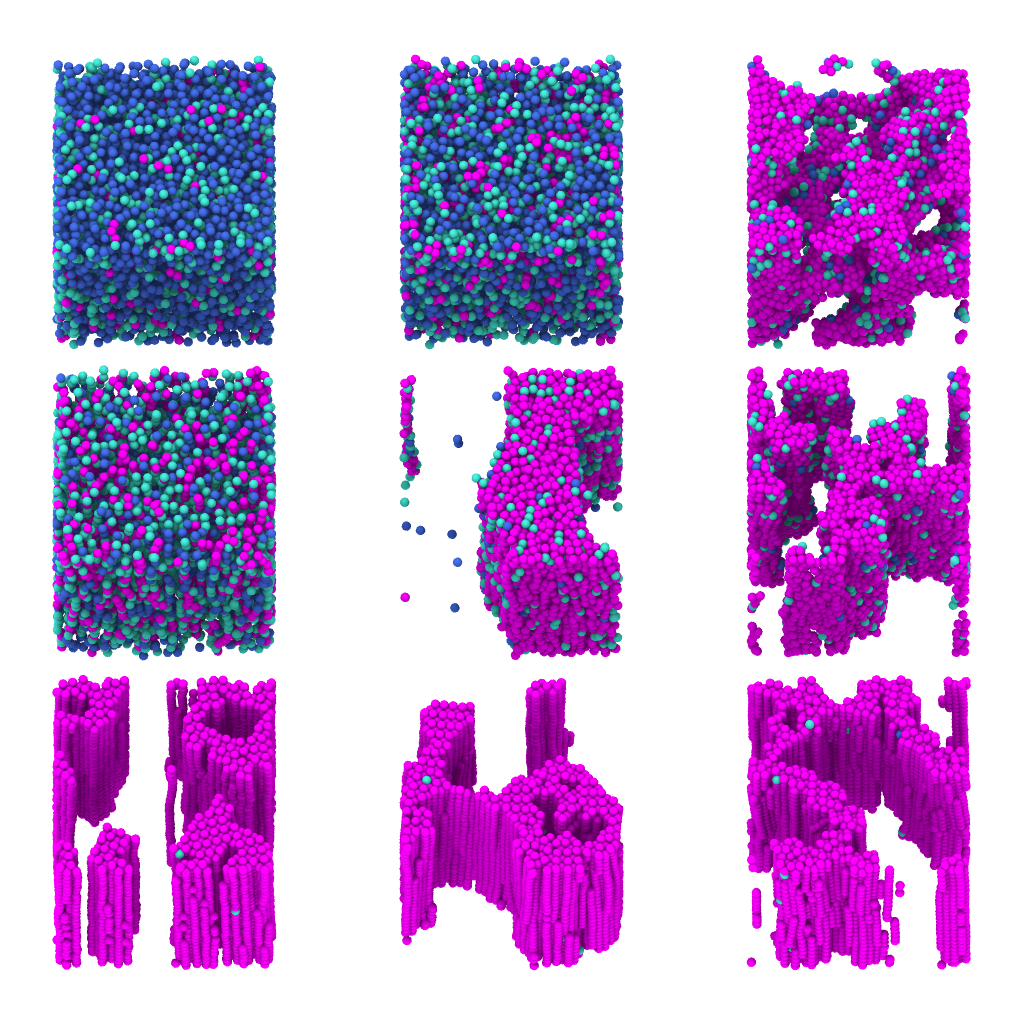

In [16]:
view='top'
size = (1024, 1024)
outfile = 'g6.png'

# Get a temporary file to write the sample
tmp_file = tempfile.NamedTemporaryFile(mode='w', suffix='.xyz', delete=False, delete_on_close=True)

# Self-contained Ecombined_order_parametersYZ dump (it is not clean to use trajectories here)
with open(tmp_file.name, 'w') as tmp:
    tmp.write('{}\n'.format(len(combined_atoms.get_positions())))
    tmp.write('Properties=species:S:1:pos:R:3:radius:R:1:color:R:3 Lattice="{},0.,0.,0.,{},0.,0.,0.,{}"\n'.format(
    *combined_atoms.cell.lengths()))
    for i, pos in enumerate(combined_atoms.get_positions()):
        tmp.write('{} {} {} {} {} {} {} {}\n'.format(1, *pos, 0.6, *cls.to_rgb(colors[labels[i]])))

pipeline = import_file(tmp_file.name)
pipeline.add_to_scene()
tmp_file.close()

vp = Viewport(type = Viewport.Type.Ortho, camera_dir = (0, 1, -2))
vp.zoom_all()

vp.render_image(filename=outfile, 
                size=size, 
                renderer=TachyonRenderer())

# Remove the temporary file
if os.path.exists(tmp_file.name):
    os.remove(tmp_file.name)

# Clear the scene
pipeline.remove_from_scene()
del pipeline

display(Image(outfile))
# Remove the output image file
os.remove(outfile)


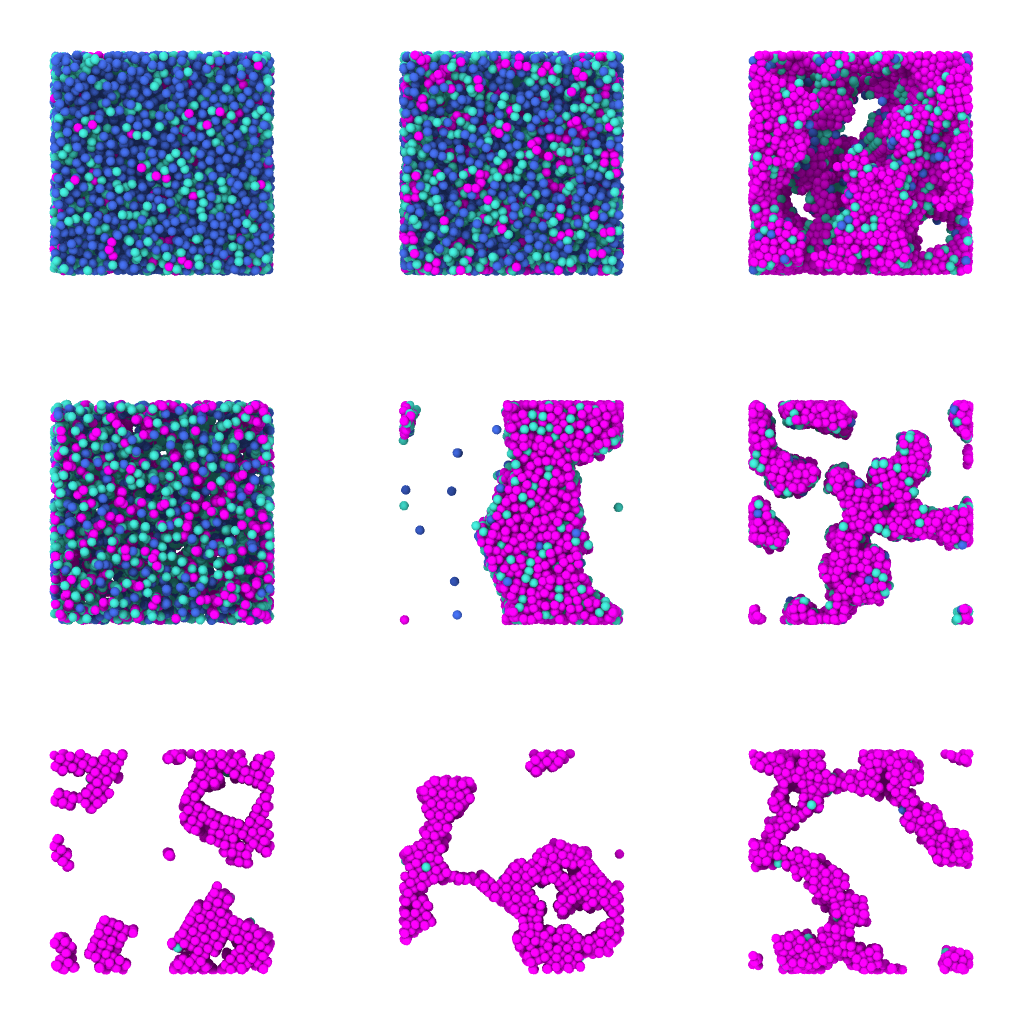

In [17]:
view='top'
size = (1024, 1024)
outfile = 'g7.png'


# Get a temporary file to write the sample
tmp_file = tempfile.NamedTemporaryFile(mode='w', suffix='.xyz', delete=False, delete_on_close=True)

# Self-contained Ecombined_order_parametersYZ dump (it is not clean to use trajectories here)
with open(tmp_file.name, 'w') as tmp:
    tmp.write('{}\n'.format(len(combined_atoms.get_positions())))
    tmp.write('Properties=species:S:1:pos:R:3:radius:R:1:color:R:3 Lattice="{},0.,0.,0.,{},0.,0.,0.,{}"\n'.format(
    *combined_atoms.cell.lengths()))
    for i, pos in enumerate(combined_atoms.get_positions()):
        tmp.write('{} {} {} {} {} {} {} {}\n'.format(1, *pos, 0.6, *cls.to_rgb(colors[labels[i]])))

# Ovito stuff. Can be customized by client code.
pipeline = import_file(tmp_file.name)
pipeline.add_to_scene()
tmp_file.close()

views = {   'top':    Viewport.Type.Top,
            'bottom': Viewport.Type.Bottom,
            'front':  Viewport.Type.Front,
            'back':   Viewport.Type.Back,
            'left':   Viewport.Type.Left,
            'right':  Viewport.Type.Right}
vp_type = views[view]
vp = Viewport(type=vp_type)
# vp = Viewport(type = Viewport.Type.Ortho, camera_dir = (2, 1, -1))
vp.zoom_all()

vp.render_image(filename=outfile, 
                size=size, 
                renderer=TachyonRenderer())

if os.path.exists(tmp_file.name):
    os.remove(tmp_file.name)

# Scene is a singleton, so we must clear it
pipeline.remove_from_scene()
del pipeline

display(Image(outfile))
os.remove(outfile)
